# NYC Airbnb Room Type Classification

**Dataset:** [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) (Kaggle)

**Goal:** Predict the `room_type` of an Airbnb listing (`Entire home/apt`, `Private room`, or `Shared room`)
using listing attributes such as price, location, availability, and review activity.

**What this notebook covers (the full ML lifecycle):**

1. Problem framing & data loading
2. Exploratory Data Analysis (EDA) — univariate, bivariate, skewness, outliers
3. Data cleaning & feature engineering
4. Train / test split
5. Preprocessing with `ColumnTransformer` + `Pipeline`
6. Baseline model
7. Multiple candidate algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
8. Model comparison (cross-validation)
9. Hyperparameter tuning of the best model
10. Final evaluation on the untouched test set
11. Feature importance
12. Saving the final pipeline (model artifact)
13. Conclusion & next steps



## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The raw CSV downloaded from Kaggle is read directly into a pandas DataFrame.

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))
df.head()

/home/likesh-kumar-sahu/small-projects/NYC-Airbnb-Room-Type-Predictor-main/nyc-ml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/likesh-kumar-sahu/.cache/kagglehub/datasets/dgomonov/new-york-city-airbnb-open-data/versions/3


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
df.shape

(48895, 16)

## 3. Exploratory Data Analysis (EDA)

We explore the data in the standard order every ML engineer follows:

- Missing values
- Univariate analysis (one variable at a time — distributions, skewness)
- Bivariate analysis (relationship between features and the target)
- Correlation between numeric features
- Outlier inspection


### 3.1 Missing Values

In [6]:
missing = df.isnull().sum()
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

### 3.2 Target Variable — `room_type`

<Axes: xlabel='room_type', ylabel='count'>

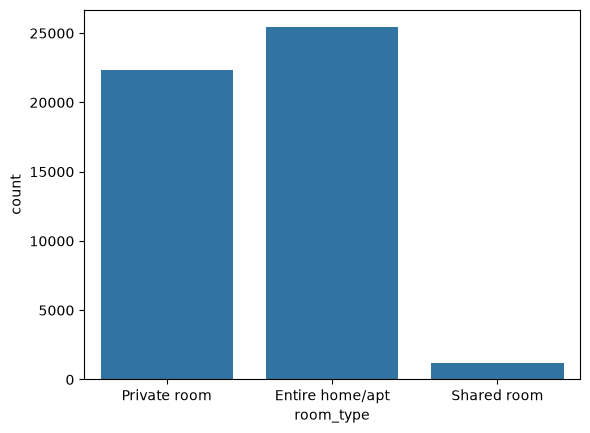

In [7]:
df['room_type'].value_counts()

sns.countplot(x='room_type',data=df)

The classes are imbalanced -> Shared Room is a Small Minority.

### 3.3 Univariate Analysis — Numeric Features

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

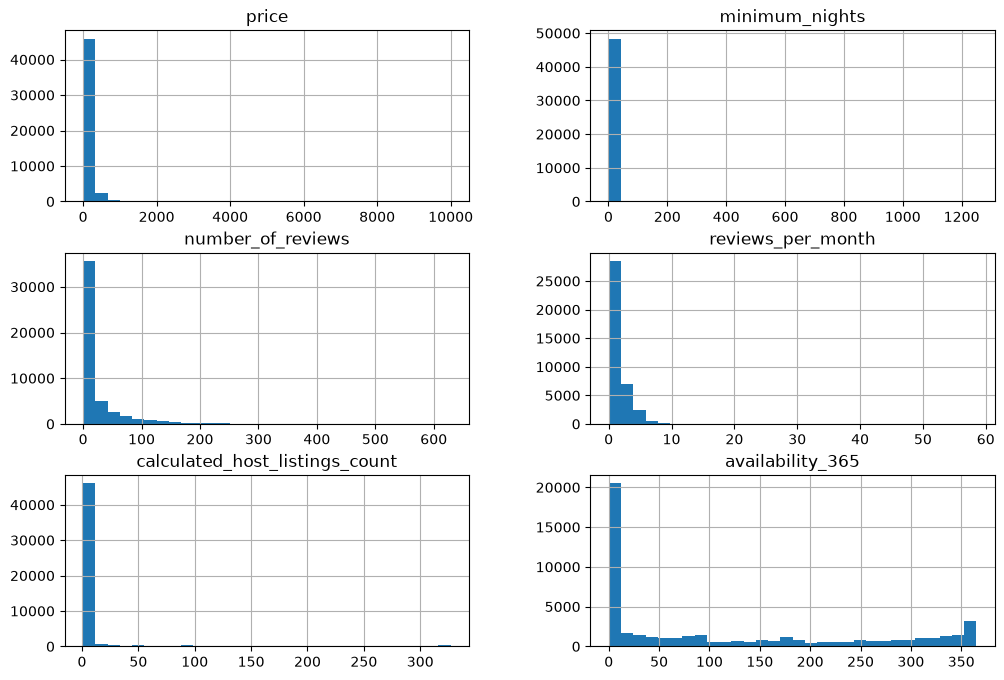

In [8]:
numerical_cols = ["price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]

df[numerical_cols].hist(bins=30, figsize=(12, 8))

### 3.4 Univariate Analysis — Categorical Features

<Axes: xlabel='neighbourhood_group', ylabel='count'>

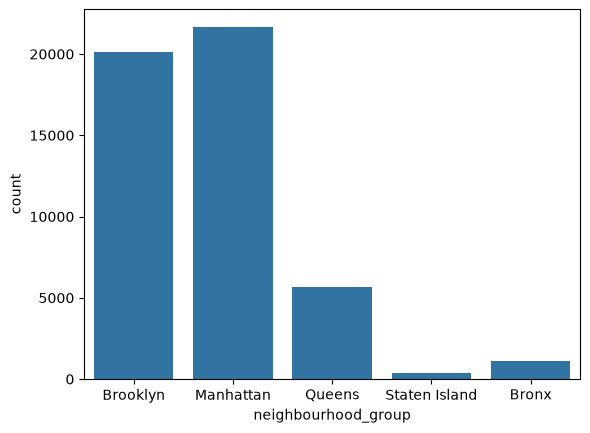

In [9]:
sns.countplot(data=df, x='neighbourhood_group')

### 3.5 Bivariate Analysis — Features vs Target

<Axes: xlabel='room_type', ylabel='price'>

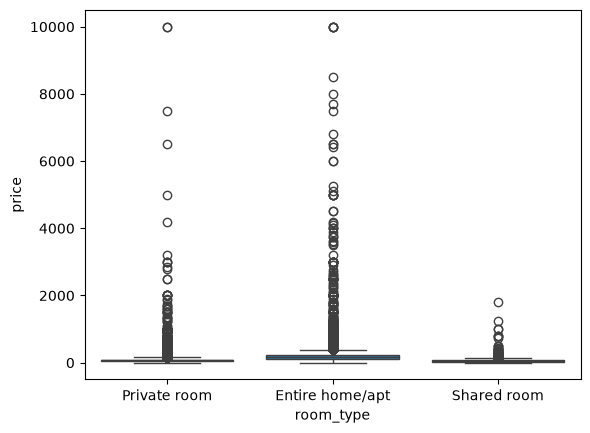

In [10]:
sns.boxplot(x='room_type', y='price', data=df)

### 3.6 Correlation Between Numeric Features

<Axes: >

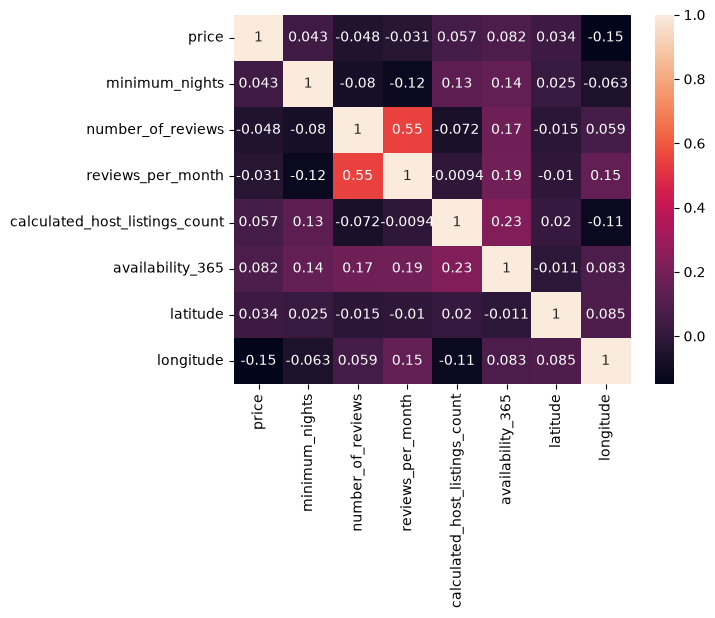

In [11]:
corr = df[numerical_cols + ['latitude', 'longitude']].corr()
sns.heatmap(corr,annot=True
            )

### 3.7 Geographic Distribution (Bonus Visual)

<Axes: xlabel='longitude', ylabel='latitude'>

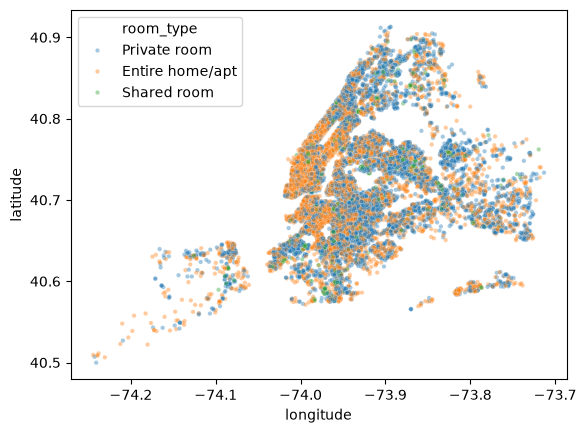

In [12]:
sns.scatterplot(x='longitude', y='latitude',data=df, hue='room_type', alpha=0.4, s=10)

## 4. Data Cleaning & Feature Engineering

Steps:
1. Drop columns that are pure identifiers or free text and carry no generalizable signal for a
   tabular model (`id`, `name`, `host_id`, `host_name`, `last_review`).
2. Fill missing `reviews_per_month` with `0` (no reviews yet).
3. Cap extreme outliers in `price` and `minimum_nights` using percentile clipping, so a handful of
   data-entry errors (e.g. $10,000/night, 1,250 minimum nights) don't distort the model.
4. Separate features (`X`) from the target (`y`).


In [13]:
#1. Drop Colunmns that dont help us.
df_clean = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])

#2. No reviews yet -> 0 reviews per month, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)



In [14]:
#3. Cap Extreme outliers instead of deleting rows.

price_cap  = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)


# df_clean = df_clean[df_clean['price'] < price_cap]
# df_clean = df_clean[df_clean['minimum_nights'] < nights_cap]


In [15]:
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

## 5. Train / Test Split

We hold out 20% of the data as a **test set** that is never touched during model selection or
tuning — it is only used once, at the very end, to report the final, honest performance.
`stratify=y` keeps the same class proportions in both splits, which matters because the target is
imbalanced.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

In [17]:
#Stratisfy ye ensure krta hai ki jab bhi hum split ya sample kare , har group(class) ka Original Propotion maintain rahe.

## 6. Preprocessing: `ColumnTransformer` + `Pipeline`

Production ML code should never manually transform train/test data with separate lines — it's
error-prone and leaks information. Instead we build a single, reusable `ColumnTransformer`:

- **Numeric features** → median imputation + standard scaling
- **Categorical features** → most-frequent imputation + one-hot encoding

This transformer will be the first step of *every* model pipeline below, so preprocessing is
learned only on training data and applied consistently everywhere (no data leakage).

In [18]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [19]:
numerical_cols = ["latitude","longitude","price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]

categorical_cols = ['neighbourhood_group', 'neighbourhood']

#1. Pipeline -> for Numeric Columns
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="median")),
    ('scale', StandardScaler())
])


#2. Pipeline -> for Categorical Columns
categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numeric_pipeline, numerical_cols),
    ("categorical", categorical_pipeline, categorical_cols )
])

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['latitude', 'longitude', 'price',
                                  'minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [20]:
df_clean['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

## 8. Trying Multiple Algorithms

We now compare several models, each wrapped in its own pipeline with the **same** preprocessor. We
evaluate each with 3-fold **stratified cross-validation** on the training set (never touching the
test set yet), so the comparison is fair and robust.

Models tried:
1. Logistic Regression — simple, interpretable linear baseline
2. Decision Tree — a single non-linear model, prone to overfitting
3. Random Forest — an ensemble of trees, usually a strong general-purpose model
4. Gradient Boosting — sequential ensemble, often the most accurate of the classics


**SMOTE (Synthetic Minority Oversampling)**.                         
for class IMbalance
-----------------------------------------
1. High chances of Overfitting.
2. Data Leakage

In [21]:
import warnings
warnings.filterwarnings('ignore')

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score


In [23]:
# class_weight="Balanced" tells the model to pay more attention to the minority class
# or rare class (Shared Room)
# but the problem is GradintBossting doesnt support class weight so we left it as it is.

models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced",random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest"       : RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])

    # Accuracy alone can be misleading on imbalanced classes, so we use macro f1
    # both: plain accuracy and macro f1 (which treats every class equally)

    accuracy = cross_val_score(pipe, X_train, y_train,cv=3,scoring="accuracy")
    macrof1 = cross_val_score(pipe, X_train, y_train,cv=3,scoring="f1_macro")

    print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")

Logistic Regression -> Accuracy: 0.659 , F1: 0.522
Decision Tree -> Accuracy: 0.782 , F1: 0.647
Random Forest -> Accuracy: 0.851 , F1: 0.715
Gradient Boosting -> Accuracy: 0.850 , F1: 0.705


## 9. Hyperparameter Tuning

We pick the best-performing model from the comparison above (whichever one that turns out to be) and
search over *its* key hyperparameters using `RandomizedSearchCV` (cheaper than an exhaustive grid
search, while still exploring the space well). We keep optimizing for **macro-F1** since the classes
are imbalanced.

In [24]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "classifier__n_estimators" : [100,200,150,300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
    )

search.fit(X_train, y_train)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['latitude',
                                                                                'longitude',
                                                                                'price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365']),
                                                                              ('categ...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encode',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced'))]),
                   param_distributions={'classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [25]:
print("Best Parameters: ", search.best_params_)
print("Best CV Macro-F1: ", search.best_score_)

Best Parameters:  {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}
Best CV Macro-F1:  0.7299353463101826


## 10. Final Evaluation on the Test Set

This is the *only* time we touch the held-out test set. It gives us an honest estimate of how the
final tuned model would perform on completely unseen listings.

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score
best_pipeline = search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average="macro")}")

Accuracy Score: 0.8549826474962816
F1 Score: 0.7346211118766517


<Axes: >

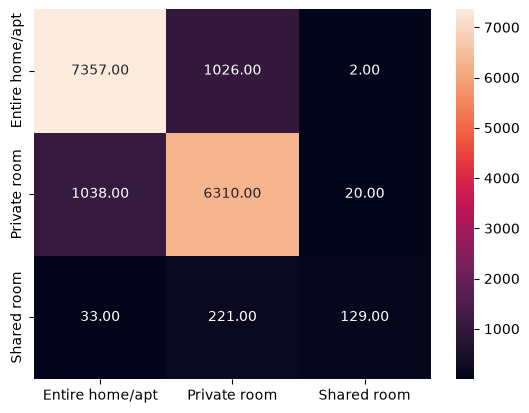

In [27]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f",
            xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)


## 11. Saving the Final Model Artifact

In production, the entire pipeline (preprocessing **and** model together) is serialized as a single
artifact, so a new listing can be scored with one call  no manual preprocessing required at
inference time.

In [28]:
import joblib

joblib.dump(best_pipeline, "Model_Pipeline.pkl",compress=3)

['Model_Pipeline.pkl']

In [29]:
df_clean.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')